# Data Analysis Notebook

# Import Dependencies

In [168]:
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer

from Bio import SeqIO
from Bio.SeqUtils import gc_fraction

# Load Data

In [170]:
LABEL_MAP = {
    # Label for Influenza
    "Influenza A": "influenza A",
    "Influenza B": "influenza B",
    "Influenza C": "influenza C",
    "Influenza D": "influenza D",
}

In [171]:
def assign_label(description: str) -> str:
    for keyword, label in LABEL_MAP.items():
        if keyword.lower() in description.lower():
            return label
    return None

In [172]:
def fasta_to_dataframe(fasta_path: str) -> pd.DataFrame:
    records = list()
    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = record.seq

        records.append({
            "accession": record.id,
            "description": record.description,
            "length":len(seq),
            "gc_content": round(gc_fraction(seq)*100, 2),
            "sequence": str(seq),
            "label": assign_label(record.description),
        })

    return pd.DataFrame(records)

In [188]:
df = fasta_to_dataframe("../data/sequences.fasta")
df.head()

,accession,description,length,gc_content,sequence,label
0,NC_036615.1,NC_036615.1 |Influenza D virus (D/swine/Oklaho...,2330,40.26,GGCATAAGCAGAGGATTTTATAACAATGGAAATAAACCCATATCTA...,influenza D
1,NC_036616.1,NC_036616.1 |Influenza D virus (D/swine/Oklaho...,2364,39.89,GGCATAAGCAGAGGATGTCACTACTATTAACGCTCGCAAAAGAGTA...,influenza D
2,NC_036617.1,NC_036617.1 |Influenza D virus (D/swine/Oklaho...,1775,44.00,GGCATAAGCAGGAGATTATTAAGCAATATGGACTCAACAAAAGCCC...,influenza D
3,NC_036618.1,NC_036618.1 |Influenza D virus (D/swine/Oklaho...,2049,43.34,AGCATAAGCAGGAGATTTTCAAAGATGTTTTTGCTTCTAGCAACAA...,influenza D
4,NC_036619.1,NC_036619.1 |Influenza D virus (D/swine/Oklaho...,2195,39.54,GGCATAAGCAGGAGATTTAGAAATGTCTAGTGTAATCAGAGAAATC...,influenza D


# Data Cleaning and Quality Checks

In [189]:
def extract_subtype(description: str) -> str | None:
    match = re.search(r'H\d+N\d+', description)  # no parentheses, cleaner label
    if match:
        return match.group()  # returns e.g. 'H7N9'
    return ""


# Replace label with subtype, keep others as-is
df['label'] = df.apply(
    lambda row: extract_subtype(row['description']) 
    if row['label'] == 'influenza A' 
    else row['label'],
    axis=1
)

# Drop rows where Influenza A had no parseable subtype
df = df[df['label'].notna()]

# Check full distribution before filtering
print(df['label'].value_counts())
print(f"\nTotal before filter: {len(df)}")

# Keep only labels with 100+ samples
counts = df['label'].value_counts()
valid_labels = counts[counts >= 100].index
df = df[df['label'].isin(valid_labels)]

print(f"\nKept labels: {valid_labels.tolist()}")
print(f"Total after filter: {len(df)}")
print(df['label'].value_counts())

label
H1N1           2470
H3N2           1971
H5N1           1135
H9N2           1101
H5N2            779
H7N3            602
H7N9            421
H1N2            398
influenza B     280
H3N8            280
H5N8            200
H5N6            180
H7N7            162
influenza D     149
H4N6            128
H7N2            111
                104
H6N2            100
H4N8             72
H6N1             64
H2N2             57
H11N9            57
H7N1             46
H7N8             40
H10N7            36
H5N5             32
H3N1             24
H3N6             24
H13N6            24
H6N8             24
H7N4             23
H4N2             23
H10N8            18
H3N3             16
H13N8            16
H6N5             16
H2N3             16
influenza C      14
H13N2            12
H9N9              9
H10N9             9
H8N4              9
H9N7              8
H12N5             8
H2N7              8
H5N9              8
H13N9             8
H1N8              8
H12N8             8
H6N6          

In [193]:
# There are some errors in the description
df = df[~df["label"].isna() & (df["label"] != "")]
df.info()

<class 'pandas.DataFrame'>
Index: 10467 entries, 0 to 19047
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   accession    10467 non-null  str    
 1   description  10467 non-null  str    
 2   length       10467 non-null  int64  
 3   gc_content   10467 non-null  float64
 4   sequence     10467 non-null  str    
 5   label        10467 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 18.4 MB


In [194]:
set(df.label)

{'H1N1',
 'H1N2',
 'H3N2',
 'H3N8',
 'H4N6',
 'H5N1',
 'H5N2',
 'H5N6',
 'H5N8',
 'H6N2',
 'H7N2',
 'H7N3',
 'H7N7',
 'H7N9',
 'H9N2',
 'influenza B',
 'influenza D'}

In [195]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
length,10467.0,1651.366294,508.614034,246.00,1398.00,1683.00,2208.00,2867.00
gc_content,10467.0,43.789051,2.188628,34.63,42.13,43.56,44.97,50.59


# Data Visualizations

## Label Distribution

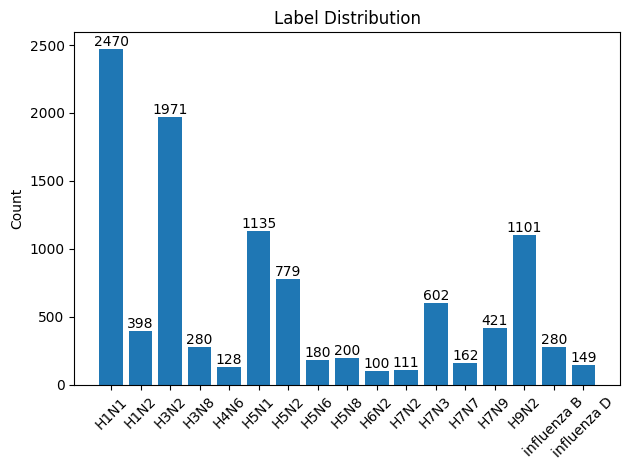

In [196]:
fig, ax = plt.subplots()

counts = df["label"].value_counts().sort_index()
ax.bar(counts.index, counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Label Distribution")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## Sequence Visualization

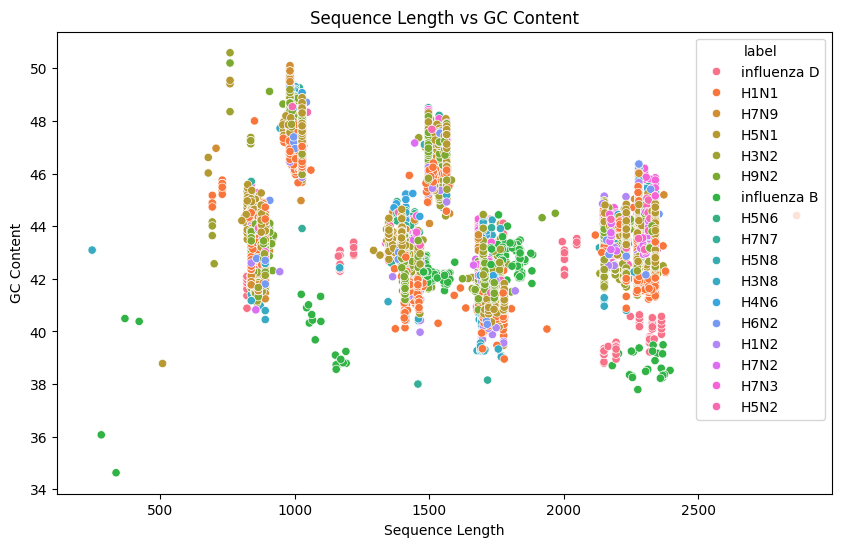

In [197]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='length', y='gc_content', hue='label')

plt.title('Sequence Length vs GC Content')
plt.xlabel('Sequence Length')
plt.ylabel('GC Content')

plt.show()

In [198]:
vectorizer = CountVectorizer(analyzer="char", ngram_range=(3, 3))
kmer_matrix = vectorizer.fit_transform(df['sequence'])
kmer_names = vectorizer.get_feature_names_out()
kmer_df = pd.DataFrame(kmer_matrix.toarray(), columns=kmer_names, index=df.index)
kmer_freq_df = kmer_df.div(df['length'], axis=0)
kmer_freq_df["label"]=df["label"]

mean_kmer_freqs = kmer_freq_df.groupby('label').mean()
mean_kmer_freqs.iloc[:, :5]

,aaa,aac,aag,aak,aam
label,,,,,
H1N1,0.036587,0.019526,0.026125,0.000000e+00,0.000000e+00
H1N2,0.035538,0.019705,0.026457,0.000000e+00,0.000000e+00
H3N2,0.036358,0.020943,0.026532,7.196549e-07,7.059097e-07
H3N8,0.035607,0.020541,0.025702,0.000000e+00,0.000000e+00
H4N6,0.030742,0.020105,0.025984,0.000000e+00,0.000000e+00
H5N1,0.033238,0.019524,0.024696,0.000000e+00,0.000000e+00
H5N2,0.031365,0.019783,0.025604,0.000000e+00,0.000000e+00
H5N6,0.032844,0.020733,0.025478,0.000000e+00,0.000000e+00
H5N8,0.032048,0.019341,0.026117,0.000000e+00,0.000000e+00


## PCA Visualization

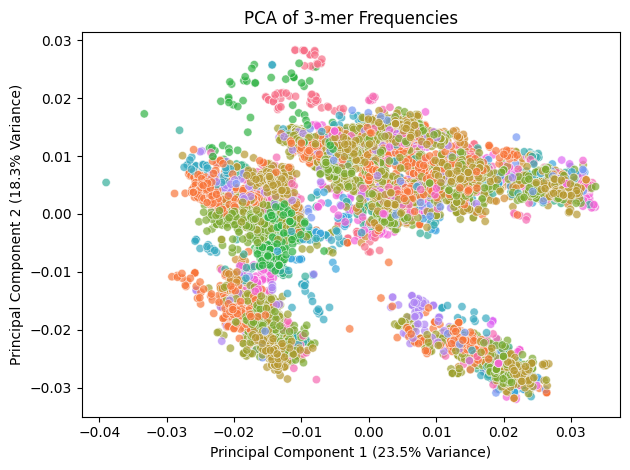

In [205]:
X = kmer_freq_df.drop('label', axis=1)
y = kmer_freq_df['label']

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['label'] = y.values

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label',
    alpha=0.7,
)
plt.title('PCA of 3-mer Frequencies')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend().remove()
plt.tight_layout()
plt.savefig("../figures/pca_results_3mer_freq.jpg")
plt.show()

## TSNE Visualization

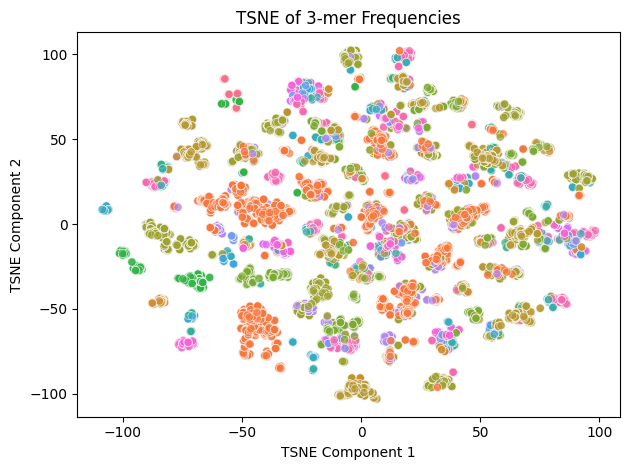

In [206]:
tsne = TSNE(n_components=2)
tsne_components = tsne.fit_transform(X)

tsne_df = pd.DataFrame(data=tsne_components, columns=['TSNE1', 'TSNE2'])
tsne_df['label'] = y.values


sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='label',
    alpha=0.7,
)
plt.title('TSNE of 3-mer Frequencies')
plt.xlabel(f'TSNE Component 1')
plt.ylabel(f'TSNE Component 2')
plt.legend().remove()
plt.tight_layout()
plt.savefig("../figures/tsne_results_3mer_freq.jpg")
plt.show()

## UMAP Visualization

/home/nifdi/miniconda3/envs/tcgabio/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


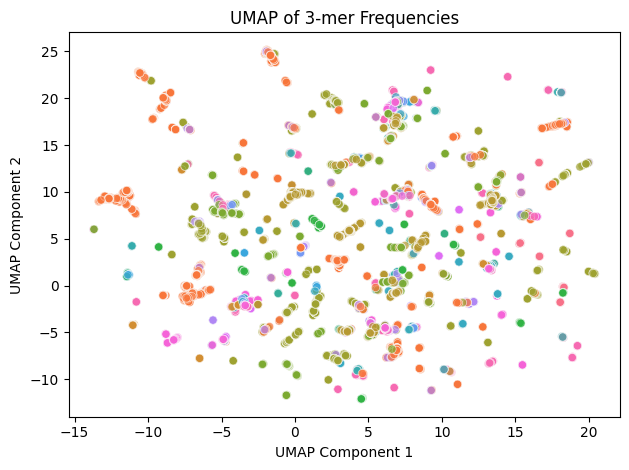

In [207]:
reducer = umap.UMAP(n_components=2)
umap_components = reducer.fit_transform(X)

umap_df = pd.DataFrame(data=umap_components, columns=['UMAP1', 'UMAP2'])
umap_df['label'] = y.values


sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='label',
    alpha=0.7,
)
plt.title('UMAP of 3-mer Frequencies')
plt.xlabel(f'UMAP Component 1')
plt.ylabel(f'UMAP Component 2')
plt.legend().remove()
plt.tight_layout()
plt.savefig("../figures/umap_results_3mer_freq.jpg")
plt.show()

In [202]:
df[['accession', 'length', 'gc_content', 'sequence', 'label']].to_csv("../data/cleaned_data.csv", index=None)
pd.read_csv("../data/cleaned_data.csv")

,accession,length,gc_content,sequence,label
0,NC_036615.1,2330,40.26,GGCATAAGCAGAGGATTTTATAACAATGGAAATAAACCCATATCTA...,influenza D
1,NC_036616.1,2364,39.89,GGCATAAGCAGAGGATGTCACTACTATTAACGCTCGCAAAAGAGTA...,influenza D
2,NC_036617.1,1775,44.00,GGCATAAGCAGGAGATTATTAAGCAATATGGACTCAACAAAAGCCC...,influenza D
3,NC_036618.1,2049,43.34,AGCATAAGCAGGAGATTTTCAAAGATGTTTTTGCTTCTAGCAACAA...,influenza D
4,NC_036619.1,2195,39.54,GGCATAAGCAGGAGATTTAGAAATGTCTAGTGTAATCAGAGAAATC...,influenza D
...,...,...,...,...,...
10462,AF389122.1,890,44.72,AGCAAAAGCAGGGTGACAAAGACATAATGGATCCAAACACTGTGTC...,H1N1
10463,AF251391.1,988,47.87,TATTGAAAGATGAGCCTTCTAACCGAGGTCGAAACGTATGTTCTCT...,H3N2
10464,AF102656.1,1350,44.30,ATGAATCCAAATCAGAAGATAATAACCATTGGATCAATCTGCATGG...,H5N1
10465,J02150.1,890,44.27,AGCAAAAGCAGGGTGACAAAGACATAATGGATCCAAACACTGTGTC...,H1N1
